# XGBoost Prediction Plots

This notebook loads the saved XGBoost pipeline artifact, evaluates it on the test split, and saves two plots:

1. Actual vs. Predicted scatter plot (color-coded by price band).
2. Prediction accuracy by price band (actual vs. predicted median prices).

In [3]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pricing_lab.data import load_train_test

In [5]:
MODEL_PATH = PROJECT_ROOT / "artifacts/xgboost.joblib"
PLOTS_DIR = PROJECT_ROOT / "artifacts/plots"
SCATTER_PLOT_PATH = PLOTS_DIR / "xgboost_actual_vs_predicted_by_band.png"
BAND_BAR_PLOT_PATH = PLOTS_DIR / "xgboost_prediction_accuracy_by_band.png"
BAND_LABELS = ["Low", "Mid", "High"]
BAND_COLORS = {
    "Low": "#2ca02c",
    "Mid": "#1f77b4",
    "High": "#d62728",
}

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing model artifact at {MODEL_PATH}. Run training with --model-output-dir artifacts first."
    )

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
data = load_train_test()
xgboost_pipeline = joblib.load(MODEL_PATH)
predicted_log_prices = xgboost_pipeline.predict(data.X_test)

actual_prices = np.expm1(data.y_test.to_numpy())
predicted_prices = np.expm1(predicted_log_prices)

evaluation_frame = pd.DataFrame(
    {
        "actual_price": actual_prices,
        "predicted_price": predicted_prices,
    }
)
evaluation_frame["price_band"] = pd.qcut(
    evaluation_frame["actual_price"],
    q=3,
    labels=BAND_LABELS,
)
evaluation_frame.head()

/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVe

,actual_price,predicted_price,price_band
0,150.0,86.441513,High
1,50.0,62.128185,Low
2,28.0,105.013771,Low
3,120.0,150.532349,Mid
4,50.0,72.616776,Low


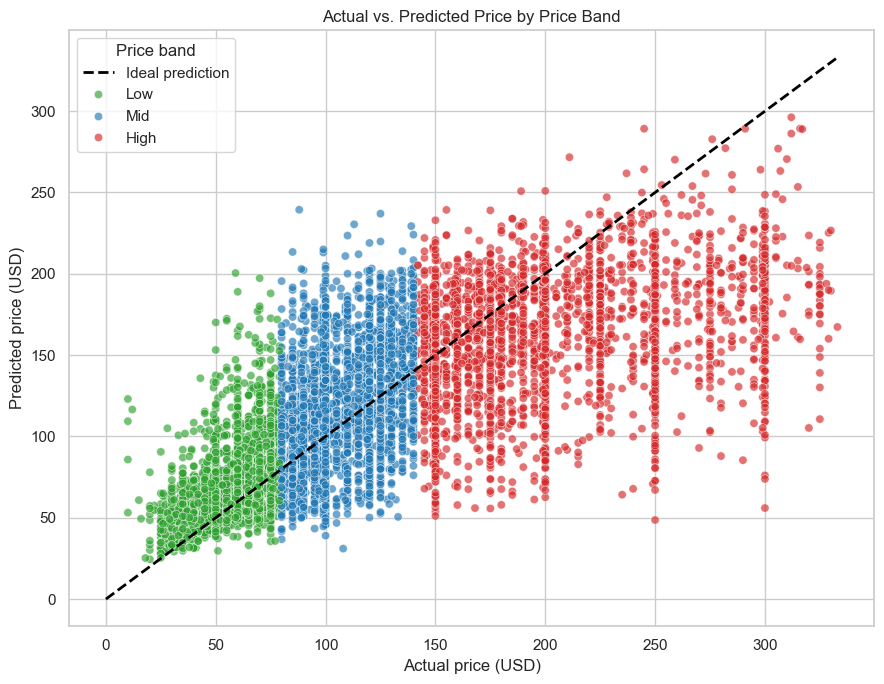

Saved scatter plot to /Users/Kushal/Projects/BNB_Pricing/artifacts/plots/xgboost_actual_vs_predicted_by_band.png


In [9]:
sns.set_theme(style="whitegrid")
fig, axis = plt.subplots(figsize=(9, 7))

maximum_axis_value = max(
    float(evaluation_frame["actual_price"].max()),
    float(evaluation_frame["predicted_price"].max()),
)
axis.plot(
    [0, maximum_axis_value],
    [0, maximum_axis_value],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Ideal prediction",
)
sns.scatterplot(
    data=evaluation_frame,
    x="actual_price",
    y="predicted_price",
    hue="price_band",
    palette=BAND_COLORS,
    alpha=0.65,
    s=36,
    ax=axis,
)
axis.set_title("Actual vs. Predicted Price by Price Band")
axis.set_xlabel("Actual price (USD)")
axis.set_ylabel("Predicted price (USD)")
axis.legend(title="Price band")
fig.tight_layout()
fig.savefig(SCATTER_PLOT_PATH, dpi=180)
plt.show()
print(f"Saved scatter plot to {SCATTER_PLOT_PATH}")

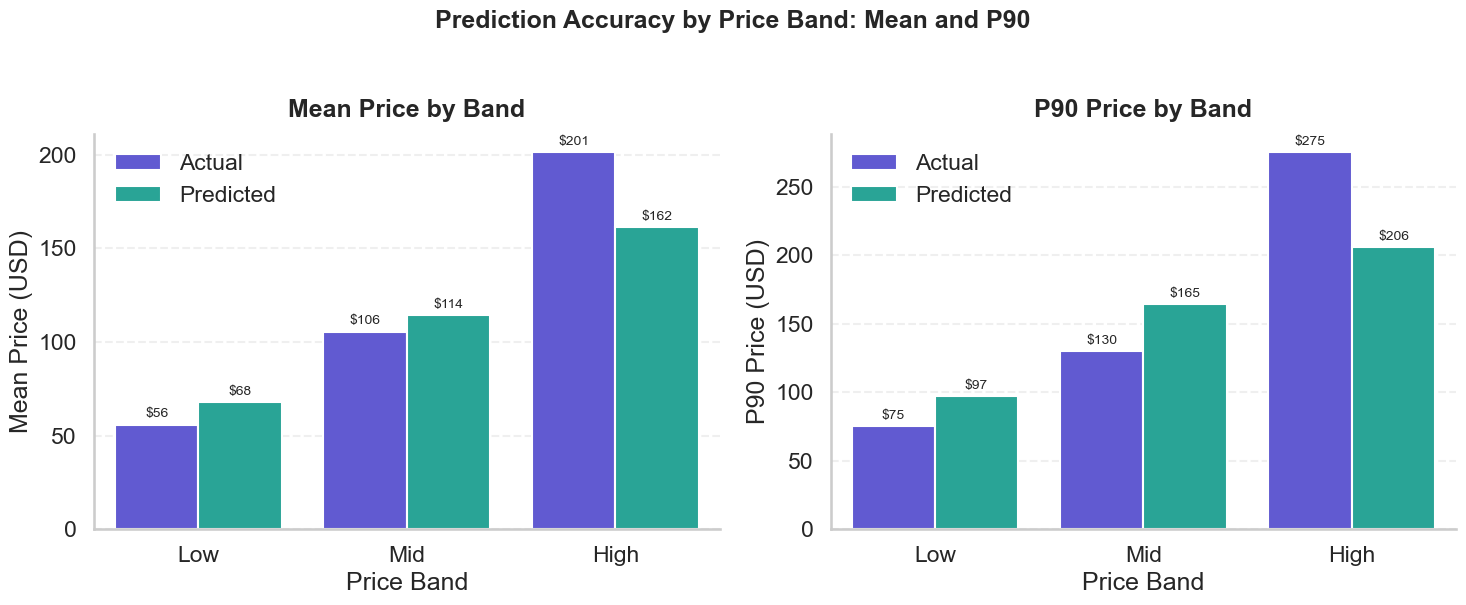

Saved price-band bar plot to /Users/Kushal/Projects/BNB_Pricing/artifacts/plots/xgboost_prediction_accuracy_by_band.png


,actual_mean,predicted_mean,actual_p90,predicted_p90
price_band,,,,
Low,55.819180,68.074364,75.0,97.167085
Mid,105.537236,114.233665,130.0,164.521445
High,201.303928,161.602417,275.0,205.811908


In [10]:
band_summary = (
    evaluation_frame.groupby("price_band", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "actual_mean": group["actual_price"].mean(),
                "predicted_mean": group["predicted_price"].mean(),
                "actual_p90": group["actual_price"].quantile(0.9),
                "predicted_p90": group["predicted_price"].quantile(0.9),
            }
        ),
        include_groups=False,
    )
    .reindex(BAND_LABELS)
)

mean_plot_frame = (
    band_summary[["actual_mean", "predicted_mean"]]
    .rename(columns={"actual_mean": "Actual", "predicted_mean": "Predicted"})
    .reset_index(names="Price band")
    .melt(id_vars="Price band", var_name="Series", value_name="Price")
)

p90_plot_frame = (
    band_summary[["actual_p90", "predicted_p90"]]
    .rename(columns={"actual_p90": "Actual", "predicted_p90": "Predicted"})
    .reset_index(names="Price band")
    .melt(id_vars="Price band", var_name="Series", value_name="Price")
)

mean_plot_path = PLOTS_DIR / "xgboost_prediction_accuracy_by_band_mean.png"
p90_plot_path = PLOTS_DIR / "xgboost_prediction_accuracy_by_band_p90.png"

sns.set_theme(style="whitegrid", context="talk")
palette = {"Actual": "#4F46E5", "Predicted": "#14B8A6"}

fig_mean, axis_mean = plt.subplots(figsize=(9, 6))
mean_bar_plot = sns.barplot(
    data=mean_plot_frame,
    x="Price band",
    y="Price",
    hue="Series",
    palette=palette,
    ax=axis_mean,
)
for container in mean_bar_plot.containers:
    axis_mean.bar_label(container, fmt="$%.0f", padding=3, fontsize=10)
axis_mean.set_title("Prediction Accuracy by Price Band: Mean", pad=12, fontweight="semibold")
axis_mean.set_xlabel("Price Band")
axis_mean.set_ylabel("Mean Price (USD)")
axis_mean.legend(title="", frameon=False, loc="upper left")
axis_mean.spines["top"].set_visible(False)
axis_mean.spines["right"].set_visible(False)
axis_mean.grid(axis="y", linestyle="--", alpha=0.3)
fig_mean.tight_layout()
fig_mean.savefig(mean_plot_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved mean price-band bar plot to {mean_plot_path}")

fig_p90, axis_p90 = plt.subplots(figsize=(9, 6))
p90_bar_plot = sns.barplot(
    data=p90_plot_frame,
    x="Price band",
    y="Price",
    hue="Series",
    palette=palette,
    ax=axis_p90,
)
for container in p90_bar_plot.containers:
    axis_p90.bar_label(container, fmt="$%.0f", padding=3, fontsize=10)
axis_p90.set_title("Prediction Accuracy by Price Band: P90", pad=12, fontweight="semibold")
axis_p90.set_xlabel("Price Band")
axis_p90.set_ylabel("P90 Price (USD)")
axis_p90.legend(title="", frameon=False, loc="upper left")
axis_p90.spines["top"].set_visible(False)
axis_p90.spines["right"].set_visible(False)
axis_p90.grid(axis="y", linestyle="--", alpha=0.3)
fig_p90.tight_layout()
fig_p90.savefig(p90_plot_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved p90 price-band bar plot to {p90_plot_path}")

band_summary